In [2]:
import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from scipy import stats
import re
import xlsxwriter

In [3]:
PROJECT_DIRS = [
    ('./MLP_Project',   'MLP',  'MLP'),
    # ('./CDT_Project_w_o_TI_first_start', 'CDT',  'CDT 1-D CNN'),
    ('./CDT_Project', 'CDT',  'CDT 1-D CNN'),
    ('./LSTM_Project',  'LSTM', 'LSTM Attention'),
    ('./CNN_Project',  'CNN', 'Regular CNN')
]

PLOTS_DIR = './Master_Thesis_Results'
os.makedirs(PLOTS_DIR, exist_ok=True)

In [4]:
plt.rcParams.update({
    'font.family': 'serif', 'font.serif': ['Times New Roman', 'DejaVu Serif'],
    'font.size': 11, 'axes.titlesize': 12, 'axes.labelsize': 11,
    'xtick.labelsize': 9, 'ytick.labelsize': 9, 'legend.fontsize': 9,
    'figure.dpi': 150, 'savefig.dpi': 300, 'grid.alpha': 0.4,
    'lines.linewidth': 1.2, 'axes.spines.top': False, 'axes.spines.right': False
})

VARIANT_COLORS = {
    # MLP (оттенки красного)
    'MLP (w TIs) [α=0.55]': '#e87c7c', 'MLP (w TIs) [α=0.80]': '#c44e52',
    'MLP (wo TIs) [α=0.55]': '#f4a4a4', 'MLP (wo TIs) [α=0.80]': '#a03030',
    
    # CDT 1-D CNN (оттенки синего)
    'CDT 1-D CNN (wo TIs) [α=0.45]': '#6a9fd8', 'CDT 1-D CNN (wo TIs) [α=0.80]': '#4c72b0',
    'CDT 1-D CNN (w TIs) [α=0.45]': "#11171d", 'CDT 1-D CNN (w TIs) [α=0.80]': "#011a44",
    
    # LSTM Attention (оттенки зеленого)
    'LSTM Attention [α=0.55]': '#7dcea0', 'LSTM Attention (wo TIs) [α=0.80]': '#27ae60',
    'LSTM Attention [α=0.55]': '#2e8b57', 'LSTM Attention (w TIs) [α=0.80]': '#1e6b40',
    
    # CNN (оттенки фиолетового: с ТИ, без ТИ, вейвлет-денойзинг)
    'CNN (w TIs) [α=0.55]': '#bb8fce', 'CNN (w TIs) [α=0.80]': '#8e44ad',
    'CNN (wo TIs) [α=0.55]': '#d2b4de', 'CNN (wo TIs) [α=0.80]': '#6c3483',
    'CNN (Wavelet wo TIs) [α=0.55]': '#a569bd', 'CNN (Wavelet wo TIs) [α=0.80]': '#4a235a',
    
    'Buy_Hold': '#888888',
}

UNIQUE_PALETTE = [
    '#e6194B', '#3cb44b', '#4363d8', '#f58231', '#911eb4', '#42d4f4',
    '#f032e6', '#bfef45', '#fabed4', '#469990', '#dcbeff', '#9A6324',
]

In [5]:
def weighted_f_score(y_true, y_pred, beta1=0.5, beta2=0.125, beta3=0.125):
    y_true, y_pred = np.asarray(y_true), np.asarray(y_pred)
    N_tu = np.sum((y_true == 1) & (y_pred == 1))
    N_td = np.sum((y_true == 2) & (y_pred == 2))
    N_tf = np.sum((y_true == 0) & (y_pred == 0))
    N_tp = N_tu + N_td + beta3 * N_tf
    E1st = np.sum((y_pred == 1) & (y_true == 2)) + np.sum((y_pred == 2) & (y_true == 1))
    E2nd = np.sum((y_pred == 1) & (y_true == 0)) + np.sum((y_pred == 2) & (y_true == 0))
    E3rd = np.sum((y_pred == 0) & (y_true == 1)) + np.sum((y_pred == 0) & (y_true == 2))
    denominator = ((1 + beta1**2 + beta2**2) * N_tp + E1st + beta1**2 * E2nd + beta2**2 * E3rd)
    return (1 + beta1**2 + beta2**2) * N_tp / denominator if denominator != 0 else 0.0

In [6]:
# def calculate_comprehensive_metrics(df, threshold=0.5, hold_period=24, commission=0.0003, rf_annual=0.09):
#     df = df.copy().sort_values('DateTime')
    
#     if pd.api.types.is_integer_dtype(df['DateTime']):
#         max_val = df['DateTime'].max()
#         unit = 'ns' if max_val > 1e17 else 'us' if max_val > 1e14 else 'ms' if max_val > 1e11 else 's'
#         df['DateTime'] = pd.to_datetime(df['DateTime'], unit=unit)
#     else:
#         df['DateTime'] = pd.to_datetime(df['DateTime'], errors='coerce')
    
#     df['Predicted'] = 0
#     df.loc[(df['Prob_Up'] > threshold) & (df['Prob_Up'] >= df['Prob_Down']), 'Predicted'] = 1
#     df.loc[(df['Prob_Down'] > threshold) & (df['Prob_Down'] > df['Prob_Up']), 'Predicted'] = 2

#     positions, current_pos, hold_counter = [], 0, 0
#     for pred in df['Predicted']:
#         if hold_counter > 0: hold_counter -= 1
#         else:
#             if pred == 1: current_pos, hold_counter = 1, hold_period - 1
#             elif pred == 2: current_pos, hold_counter = 0, hold_period - 1
#             else: current_pos, hold_counter = 0, 0
#         positions.append(current_pos)

#     df['Position'] = positions
#     df['Position'] = df['Position'].shift(1).fillna(0)
#     df['Market_Return'] = df['Price'].pct_change().fillna(0)
#     df['Strategy_Return_Gross'] = df['Position'] * df['Market_Return']
#     df['Trade_Cost'] = df['Position'].diff().abs().fillna(0) * commission
#     df['Strategy_Return_Net'] = df['Strategy_Return_Gross'] - df['Trade_Cost']
#     df['Equity'] = (1 + df['Strategy_Return_Net']).cumprod()

#     df_eval = df[(df["DateTime"] >= "2024-01-01") & (df["DateTime"] < "2026-01-01")].copy()
#     if df_eval.empty or len(df_eval) < 10: return None, {}

#     start_equity = df_eval['Equity'].iloc[0]
#     df_eval['Equity_Norm'] = df_eval['Equity'] / start_equity

#     wfs = weighted_f_score(df_eval['Actual'], df_eval['Predicted'])
#     total_return = (df_eval['Equity_Norm'].iloc[-1] / df_eval['Equity_Norm'].iloc[0] - 1) * 100
#     max_dd = ((df_eval['Equity_Norm'] / df_eval['Equity_Norm'].cummax() - 1).min()) * 100

#     df_eval['Date'] = df_eval['DateTime'].dt.date
#     daily_returns = df_eval.groupby('Date')['Strategy_Return_Net'].apply(lambda x: (1 + x).prod() - 1)
#     rf_daily = rf_annual / 252
#     excess_daily = daily_returns - rf_daily
#     sharpe = (excess_daily.mean() / excess_daily.std()) * np.sqrt(252) if excess_daily.std() > 0 else 0

#     gross_profit = daily_returns[daily_returns > 0].sum()
#     gross_loss = abs(daily_returns[daily_returns < 0].sum())
#     profit_factor = gross_profit / gross_loss if gross_loss > 0 else np.inf
#     win_rate = (daily_returns > 0).mean() * 100

#     is_significant = "No"
#     if len(daily_returns) > 30:
#         n_bootstraps = 5000
#         boot_means = np.zeros(n_bootstraps)
#         for i in range(n_bootstraps):
#             boot_sample = np.random.choice(daily_returns, size=len(daily_returns), replace=True)
#             boot_means[i] = boot_sample.mean()
#         p_value = np.mean(boot_means <= 0)
#         is_significant = "Yes" if p_value < 0.05 else "No"

#     metrics = {
#         'WFS': round(wfs, 4), 'Win Rate %': round(win_rate, 2),
#         'Profit Factor': round(profit_factor, 2), 'Return, %': round(total_return, 2),
#         'Max DD, %': round(max_dd, 2), 'Sharpe': round(sharpe, 2),
#         'Signif.': is_significant, 'Trades': int(df_eval['Position'].diff().abs().sum() / 2)
#         # УБРАЛИ BH_Return ОТСЮДА
#     }
#     return df_eval, metrics

In [7]:
def calculate_comprehensive_metrics(df, threshold=0.5, hold_period=24, commission=0.0003, rf_annual=0.09):
    df = df.copy().sort_values('DateTime')
    
    if pd.api.types.is_integer_dtype(df['DateTime']):
        max_val = df['DateTime'].max()
        unit = 'ns' if max_val > 1e17 else 'us' if max_val > 1e14 else 'ms' if max_val > 1e11 else 's'
        df['DateTime'] = pd.to_datetime(df['DateTime'], unit=unit)
    else:
        df['DateTime'] = pd.to_datetime(df['DateTime'], errors='coerce')
    
    df['Predicted'] = 0
    df.loc[(df['Prob_Up'] > threshold) & (df['Prob_Up'] >= df['Prob_Down']), 'Predicted'] = 1
    df.loc[(df['Prob_Down'] > threshold) & (df['Prob_Down'] > df['Prob_Up']), 'Predicted'] = 2

    positions, current_pos, hold_counter = [], 0, 0
    for pred in df['Predicted']:
        if hold_counter > 0: hold_counter -= 1
        else:
            if pred == 1: current_pos, hold_counter = 1, hold_period - 1
            elif pred == 2: current_pos, hold_counter = 0, hold_period - 1
            else: current_pos, hold_counter = 0, 0
        positions.append(current_pos)

    df['Position'] = positions
    df['Position'] = df['Position'].shift(1).fillna(0)
    df['Market_Return'] = df['Price'].pct_change().fillna(0)
    df['Strategy_Return_Gross'] = df['Position'] * df['Market_Return']
    df['Trade_Cost'] = df['Position'].diff().abs().fillna(0) * commission
    df['Strategy_Return_Net'] = df['Strategy_Return_Gross'] - df['Trade_Cost']
    df['Equity'] = (1 + df['Strategy_Return_Net']).cumprod()

    df_eval = df[(df["DateTime"] >= "2024-01-01") & (df["DateTime"] < "2026-01-01")].copy()
    if df_eval.empty or len(df_eval) < 10: return None, {}

    start_equity = df_eval['Equity'].iloc[0]
    df_eval['Equity_Norm'] = df_eval['Equity'] / start_equity

    wfs = weighted_f_score(df_eval['Actual'], df_eval['Predicted'])
    total_return = (df_eval['Equity_Norm'].iloc[-1] / df_eval['Equity_Norm'].iloc[0] - 1) * 100
    max_dd = ((df_eval['Equity_Norm'] / df_eval['Equity_Norm'].cummax() - 1).min()) * 100

    df_eval['Date'] = df_eval['DateTime'].dt.date
    daily_returns = df_eval.groupby('Date')['Strategy_Return_Net'].apply(lambda x: (1 + x).prod() - 1)
    rf_daily = rf_annual / 252
    excess_daily = daily_returns - rf_daily
    sharpe = (excess_daily.mean() / excess_daily.std()) * np.sqrt(252) if excess_daily.std() > 0 else 0

    gross_profit = daily_returns[daily_returns > 0].sum()
    gross_loss = abs(daily_returns[daily_returns < 0].sum())
    profit_factor = gross_profit / gross_loss if gross_loss > 0 else np.inf
    win_rate = (daily_returns > 0).mean() * 100

    is_significant = "No"
    if len(daily_returns) > 30:
        n_bootstraps = 5000
        boot_means = np.zeros(n_bootstraps)
        for i in range(n_bootstraps):
            boot_sample = np.random.choice(daily_returns, size=len(daily_returns), replace=True)
            boot_means[i] = boot_sample.mean()
        p_value = np.mean(boot_means <= 0)
        is_significant = "Yes" if p_value < 0.05 else "No"

    bh_return = (df_eval['Price'].iloc[-1] / df_eval['Price'].iloc[0] - 1) * 100
    bh_cummax = df_eval['Price'].cummax()
    bh_drawdown_series = (df_eval['Price'] / bh_cummax) - 1
    bh_max_dd = bh_drawdown_series.min() * 100
    bh_daily_returns = df_eval.groupby('Date')['Market_Return'].apply(lambda x: (1 + x).prod() - 1)
    bh_excess_daily = bh_daily_returns - rf_daily
    bh_sharpe = (bh_excess_daily.mean() / bh_excess_daily.std()) * np.sqrt(252) if bh_excess_daily.std() > 0 else 0

    alpha_return = total_return - bh_return
    dd_reduction = max_dd - bh_max_dd 

    metrics = {
        'WFS': round(wfs, 4), 'Win Rate %': round(win_rate, 2),
        'Profit Factor': round(profit_factor, 2), 
        'Return, %': round(total_return, 2),
        'Max DD, %': round(max_dd, 2), 
        'Sharpe': round(sharpe, 2),
        'B&H Return, %': round(bh_return, 2), 
        'B&H Max DD, %': round(bh_max_dd, 2),
        'B&H Sharpe': round(bh_sharpe, 2),
        'Alpha (Return), %': round(alpha_return, 2),
        'DD Reduction, %': round(dd_reduction, 2), 
        'Signif.': is_significant, 
        'Trades': int(df_eval['Position'].diff().abs().sum() / 2)
    }
    return df_eval, metrics

In [8]:
def parse_model_variant(filename, short_id):
    core_name = re.sub(r'^[A-Z]+_', '', filename)
    core_name = re.sub(r'_A\d+[\.,]\d+_probs\.parquet$', '', core_name)
    variant = re.sub(rf'^{short_id}_?', '', core_name, flags=re.IGNORECASE)
    variant = variant.replace('_', ' ').strip()
    return variant

In [9]:
all_metrics_rows = []
equity_curves_store = {}
COLORS_DYNAMIC = {}
color_counter = 0

print("Scanning local project directories...")
for proj_dir, short_id, display_base in PROJECT_DIRS:
    results_dir = proj_dir
    if not os.path.exists(results_dir):
        print(f"  [SKIP] Directory not found: {results_dir}")
        continue

    files = [f for f in os.listdir(results_dir) if f.endswith('_probs.parquet')]
    if not files: continue

    for file in sorted(files):
        alpha_match = re.search(r'_A(\d+\.\d+)_probs\.parquet', file)
        alpha_val = alpha_match.group(1) if alpha_match else "X.XX"
        
        core_name = re.sub(r'_A\d+[\.,]\d+_probs\.parquet$', '', file)
        core_name = re.sub(r'_Regular', '', core_name, flags=re.IGNORECASE)
        core_name = re.sub(r'__+', '_', core_name).strip('_')
        
        match = re.search(rf'(_|^){short_id}(_|$)', core_name, re.IGNORECASE)
        if match:
            split_idx = match.start()
            ticker = core_name[:split_idx].strip('_') 
            variant = core_name[match.end():].strip('_').replace('_', ' ')
        else:
            parts = core_name.split('_', 1)
            ticker = parts[0]
            variant = parts[1].replace('_', ' ') if len(parts) > 1 else ''
        
        model_name = f"{display_base} ({variant})" if variant else display_base
        
        model_alpha_key = f"{model_name} [α={alpha_val}]"
        
        if model_alpha_key not in COLORS_DYNAMIC:
            COLORS_DYNAMIC[model_alpha_key] = VARIANT_COLORS.get(model_alpha_key, UNIQUE_PALETTE[color_counter % len(UNIQUE_PALETTE)])
            color_counter += 1

        COLORS_DYNAMIC['Buy_Hold'] = '#888888'

        df_raw = pd.read_parquet(os.path.join(results_dir, file))

        best_sharpe, best_thresh, best_eval_df, best_metrics = -999, 0, None, None
        for thresh in np.arange(0.10, 0.90, 0.05): 
            eval_df, metrics = calculate_comprehensive_metrics(df_raw, threshold=thresh)
            
            if metrics and metrics['Trades'] > 0:
                row = {'Ticker': ticker, 'Model': model_name, 'Alpha': alpha_val, 'Threshold': thresh}
                row.update(metrics)
                all_metrics_rows.append(row)
                
                if metrics['Sharpe'] > best_sharpe:
                    best_sharpe, best_thresh, best_eval_df, best_metrics = metrics['Sharpe'], thresh, eval_df, metrics

        if best_eval_df is not None:
            if ticker not in equity_curves_store: equity_curves_store[ticker] = {}
            equity_curves_store[ticker][model_alpha_key] = (best_eval_df, best_thresh, alpha_val, model_name)
            print(f"  {ticker} | {model_name} [α={alpha_val}]: Best Sharpe={best_metrics['Sharpe']:.2f} at T={best_thresh:.2f} ({best_metrics['Trades']} trades)")

metrics_df = pd.DataFrame(all_metrics_rows)

Scanning local project directories...
  GLDRUB_TOM | MLP (w TIs) [α=0.55]: Best Sharpe=0.28 at T=0.10 (7 trades)
  GLDRUB_TOM | MLP (w TIs) [α=0.80]: Best Sharpe=0.09 at T=0.10 (7 trades)
  GLDRUB_TOM | MLP (wo TIs) [α=0.55]: Best Sharpe=0.77 at T=0.10 (6 trades)
  GLDRUB_TOM | MLP (wo TIs) [α=0.80]: Best Sharpe=0.81 at T=0.10 (28 trades)
  LKOH | MLP (w TIs) [α=0.55]: Best Sharpe=-2.01 at T=0.10 (19 trades)
  LKOH | MLP (w TIs) [α=0.80]: Best Sharpe=-1.14 at T=0.10 (17 trades)
  LKOH | MLP (wo TIs) [α=0.55]: Best Sharpe=-0.73 at T=0.10 (11 trades)
  SBER | MLP (w TIs) [α=0.55]: Best Sharpe=-1.09 at T=0.10 (19 trades)
  SBER | MLP (w TIs) [α=0.80]: Best Sharpe=-1.81 at T=0.10 (21 trades)
  SBER | MLP (wo TIs) [α=0.55]: Best Sharpe=0.08 at T=0.10 (13 trades)
  SBER | MLP (wo TIs) [α=0.80]: Best Sharpe=-0.31 at T=0.10 (12 trades)
  YDEX | MLP (w TIs) [α=0.55]: Best Sharpe=0.26 at T=0.10 (21 trades)
  YDEX | MLP (w TIs) [α=0.80]: Best Sharpe=0.18 at T=0.10 (15 trades)
  YDEX | MLP (wo TIs

In [10]:
def plot_equity_curves(data_store, plots_dir):
    tickers = list(data_store.keys())
    n_tickers = len(tickers)
    if n_tickers == 0: return
    fig, axes = plt.subplots(n_tickers, 1, figsize=(12, 4 * n_tickers), sharex=True)
    if n_tickers == 1: axes = [axes]

    fig.suptitle('Cumulative Returns: Strategies vs Buy & Hold', y=1.02, fontweight='bold')

    for i, ticker in enumerate(tickers):
        ax = axes[i]
        models_data = data_store[ticker]
        first_model_df = list(models_data.values())[0][0]
        bh_norm = first_model_df['Price'] / first_model_df['Price'].iloc[0]
        ax.plot(first_model_df['DateTime'], bh_norm, label='Buy & Hold', color=COLORS_DYNAMIC.get('Buy_Hold', '#888888'), linestyle='--', linewidth=1.5)

        # Распаковываем обновленный кортеж (4 элемента)
        for model_alpha_key, (df_eval, thresh, alpha_val, model_name) in models_data.items():
            color = COLORS_DYNAMIC.get(model_alpha_key, 'black')
            label_text = f'{model_name} (α={alpha_val})'
            ax.plot(df_eval['DateTime'], df_eval['Equity_Norm'], label=label_text, color=color, linewidth=1.5)

        ax.set_title(f'{ticker}', fontweight='bold')
        ax.set_ylabel('Cumulative Return')
        ax.legend(
            loc='upper left', 
            frameon=False,         
            fontsize=8,            
            ncol=4,
            handlelength=1.5,
            borderpad=0.5,   
            labelspacing=0.4 
        )
        ax.axhline(y=1.0, color='black', linestyle='-', alpha=0.2)
        ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
        ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))

    plt.xlabel('Date')
    plt.tight_layout()
    plt.savefig(os.path.join(plots_dir, 'equity_curves.png'), bbox_inches='tight')
    plt.show()

In [11]:
def plot_metrics_comparison(metrics_df, plots_dir):
    if metrics_df.empty: return
    best_df = metrics_df.loc[metrics_df.groupby(['Ticker', 'Model', 'Alpha'])['Sharpe'].idxmax()].copy()
    best_df['Model_Alpha'] = best_df['Model'] + ' [α=' + best_df['Alpha'].astype(str) + ']'
    
    fig, axes = plt.subplots(2, 2, figsize=(16, 10))
    fig.suptitle('Performance Metrics Comparison by Ticker and Model', fontweight='bold', y=1.02)
    
    sns.barplot(data=best_df, x='Ticker', y='Return, %', hue='Model_Alpha', ax=axes[0,0], palette=COLORS_DYNAMIC, edgecolor='black', linewidth=0.5)
    axes[0,0].axhline(0, color='gray', linewidth=0.8); axes[0,0].set_title('Total Return (%)'); axes[0,0].legend_.remove()
    
    sns.barplot(data=best_df, x='Ticker', y='Sharpe', hue='Model_Alpha', ax=axes[0,1], palette=COLORS_DYNAMIC, edgecolor='black', linewidth=0.5)
    axes[0,1].axhline(0, color='gray', linewidth=0.8); axes[0,1].axhline(1, color='gray', linestyle='--', linewidth=0.8); axes[0,1].set_title('Sharpe Ratio'); axes[0,1].legend(frameon=False, fontsize=7)
    
    sns.barplot(data=best_df, x='Ticker', y='Profit Factor', hue='Model_Alpha', ax=axes[1,0], palette=COLORS_DYNAMIC, edgecolor='black', linewidth=0.5)
    axes[1,0].axhline(1, color='gray', linewidth=0.8); axes[1,0].set_title('Profit Factor'); axes[1,0].legend_.remove()
    
    sns.barplot(data=best_df, x='Ticker', y='WFS', hue='Model_Alpha', ax=axes[1,1], palette=COLORS_DYNAMIC, edgecolor='black', linewidth=0.5)
    axes[1,1].set_title('Weighted F-Score'); axes[1,1].legend_.remove()

    for ax in axes.flat: ax.grid(axis='y', alpha=0.4)
    plt.tight_layout()
    plt.savefig(os.path.join(plots_dir, 'metrics_comparison.png'), bbox_inches='tight')
    plt.show()

In [12]:
def plot_risk_return_scatter(metrics_df, plots_dir):
    if metrics_df.empty: return
    best_df = metrics_df.loc[metrics_df.groupby(['Ticker', 'Model', 'Alpha'])['Sharpe'].idxmax()].copy()
    best_df['Model_Alpha'] = best_df['Model'] + ' [α=' + best_df['Alpha'].astype(str) + ']'
        
    plt.figure(figsize=(10, 7))
    sns.scatterplot(data=best_df, x='Sharpe', y='Return, %', hue='Model_Alpha', style='Ticker', s=150, palette=COLORS_DYNAMIC, edgecolor='black', linewidth=0.8)
    plt.axhline(0, color='gray', linestyle='--', linewidth=0.8)
    plt.axvline(0, color='gray', linestyle='--', linewidth=0.8)
    plt.axvline(1, color='gray', linestyle=':', linewidth=1, alpha=0.7, label='Sharpe = 1 & Threshold')
    plt.xlabel('Sharpe Ratio', fontweight='bold')
    plt.ylabel('Total Return (%)', fontweight='bold')
    plt.title('Risk-Adjusted Performance: Sharpe Ratio vs. Total Return', fontweight='bold')
    plt.legend(
            loc='upper left', 
            frameon=False,     
            fontsize=8,        
            ncol=4,
            handlelength=1.5,
            borderpad=0.5,   
            labelspacing=0.4 
        )
    plt.grid(True, alpha=0.4)
    plt.tight_layout()
    plt.savefig(os.path.join(plots_dir, 'risk_return_scatter.png'), bbox_inches='tight')
    plt.show()

def plot_correlation_heatmap(metrics_df, plots_dir):
    if metrics_df.empty: return
    numeric_cols = ['WFS', 'Win Rate %', 'Return, %', 'Sharpe', 'Profit Factor', 'Max DD, %', 'Trades']
    corr_matrix = metrics_df[numeric_cols].corr()
    plt.figure(figsize=(8, 6))
    mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
    sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, fmt='.2f', square=True, linewidths=0.5, mask=mask, cbar_kws={"shrink": 0.8})
    plt.title('Correlation Matrix of Strategy Metrics', fontweight='bold')
    plt.tight_layout()
    plt.savefig(os.path.join(plots_dir, 'correlation_heatmap.png'), bbox_inches='tight')
    plt.show()


Generating unified academic visualizations...


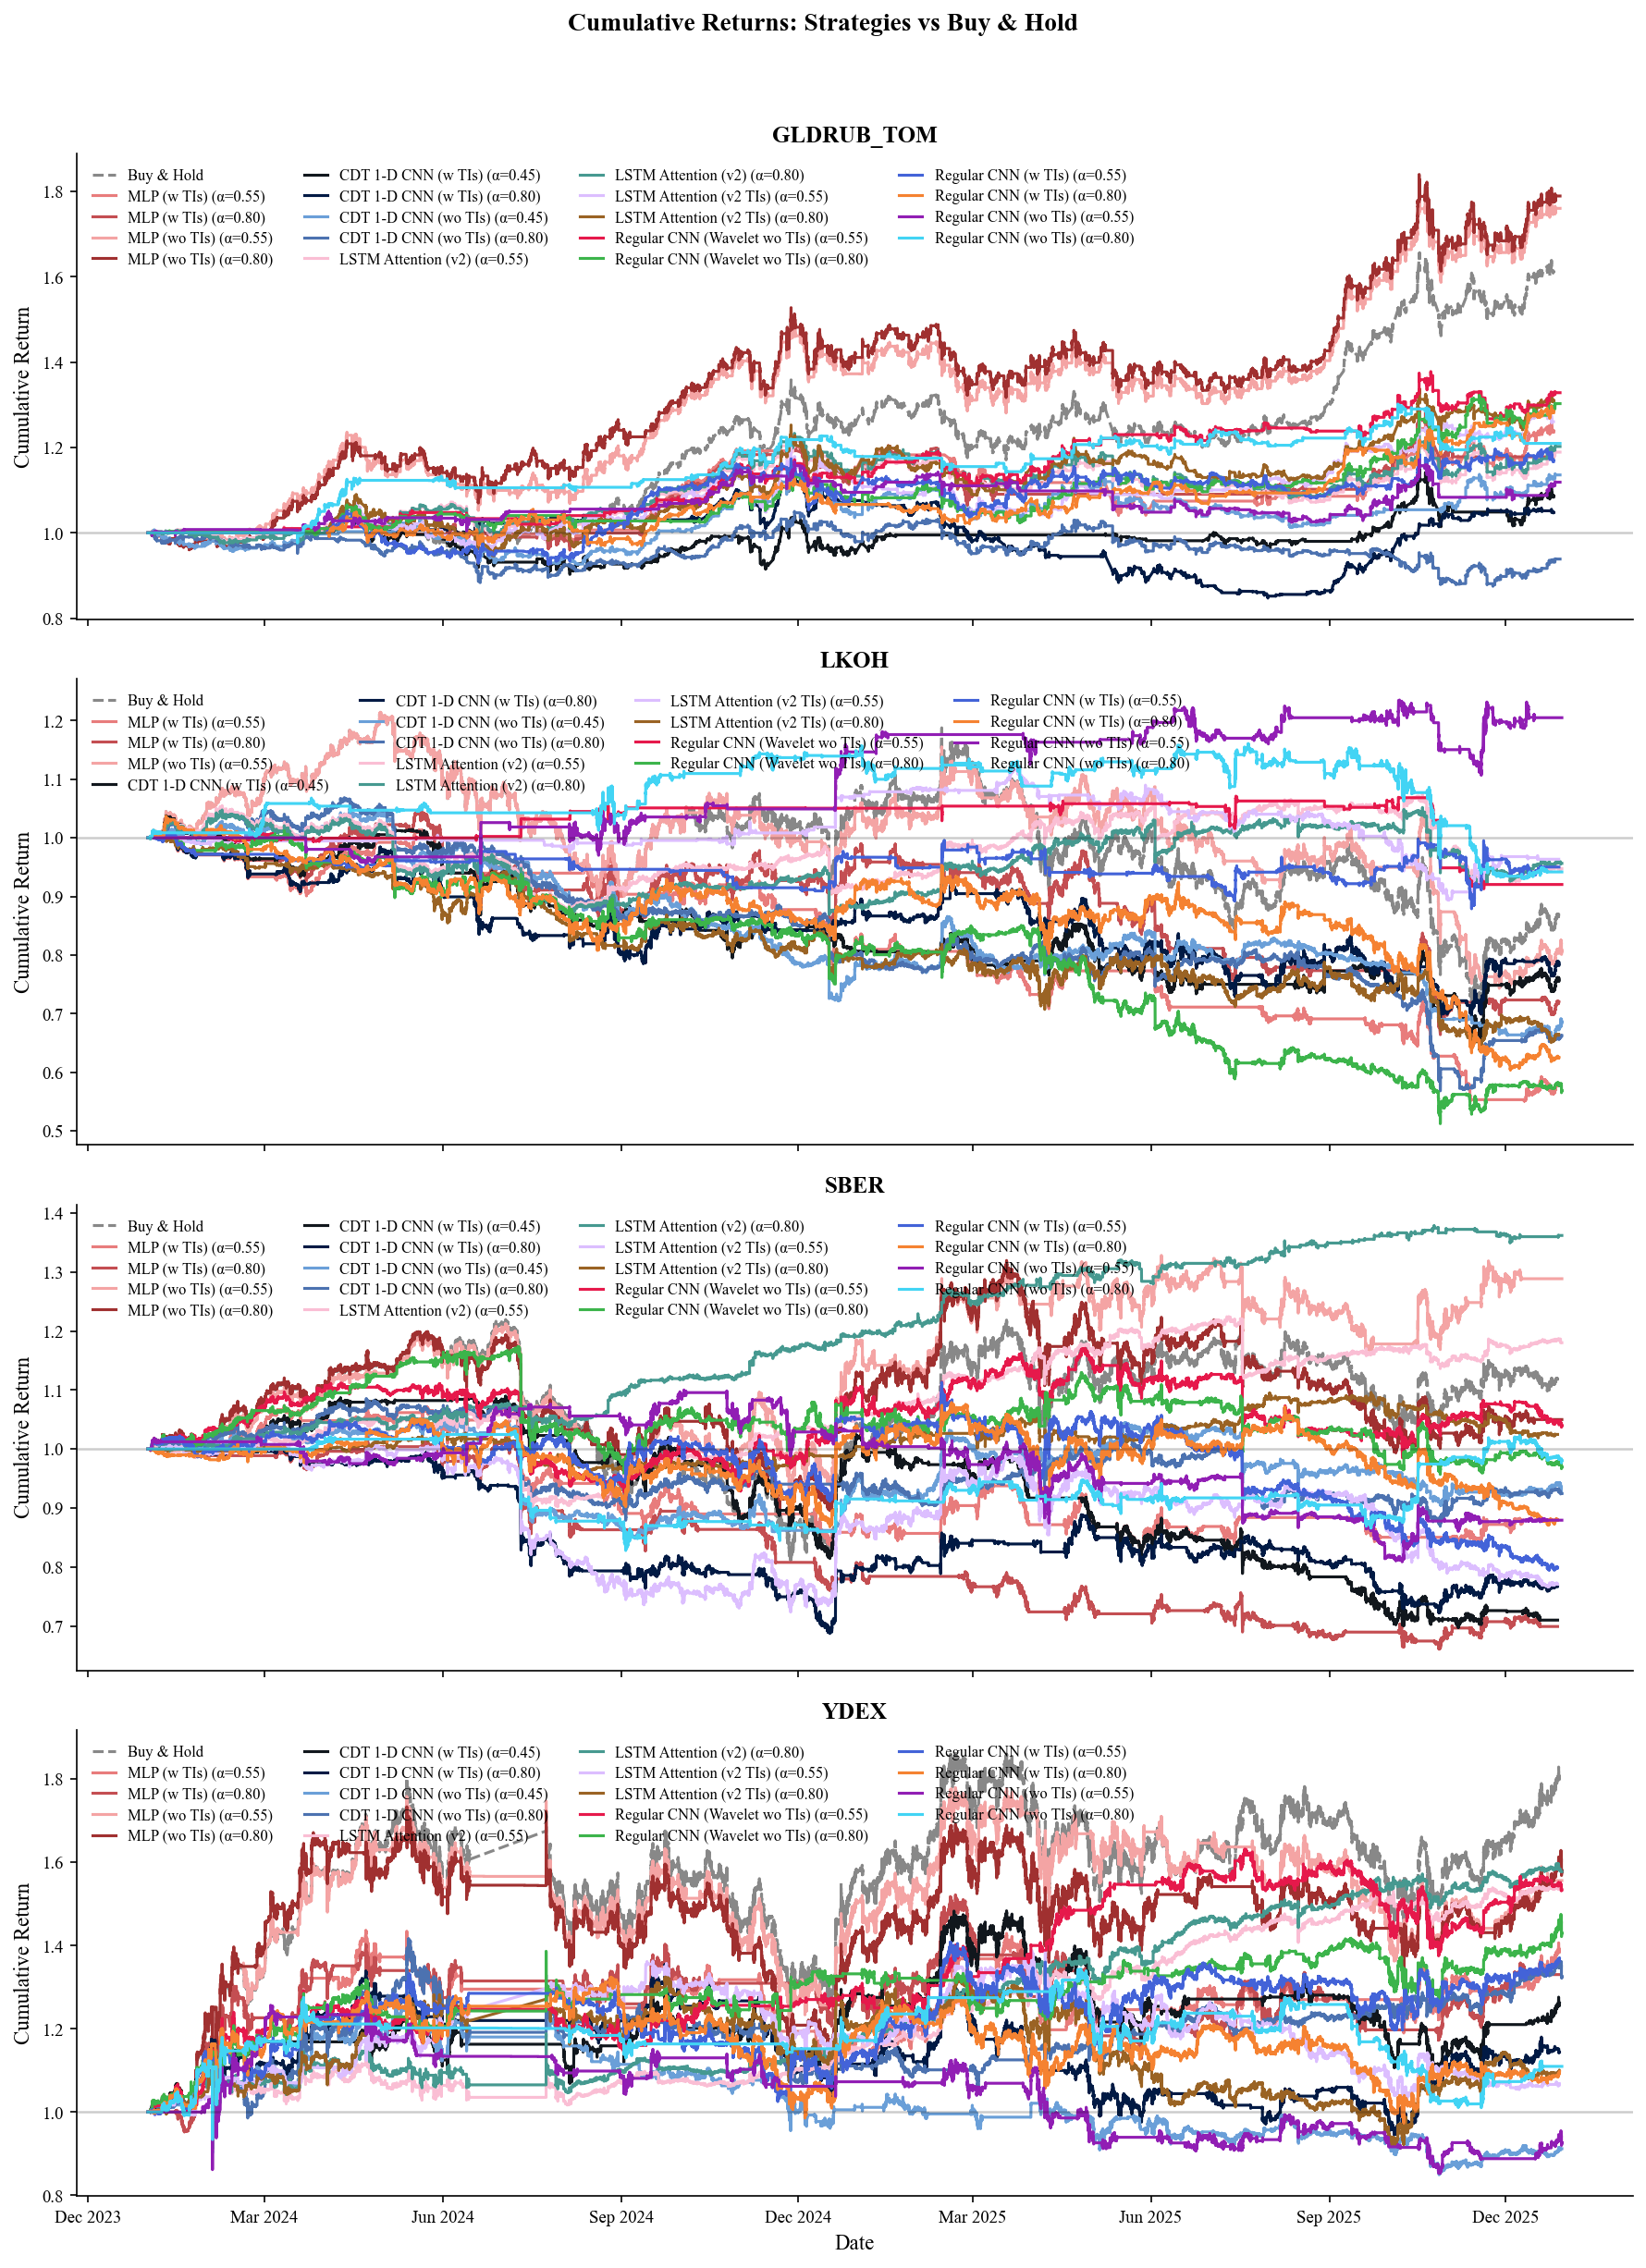

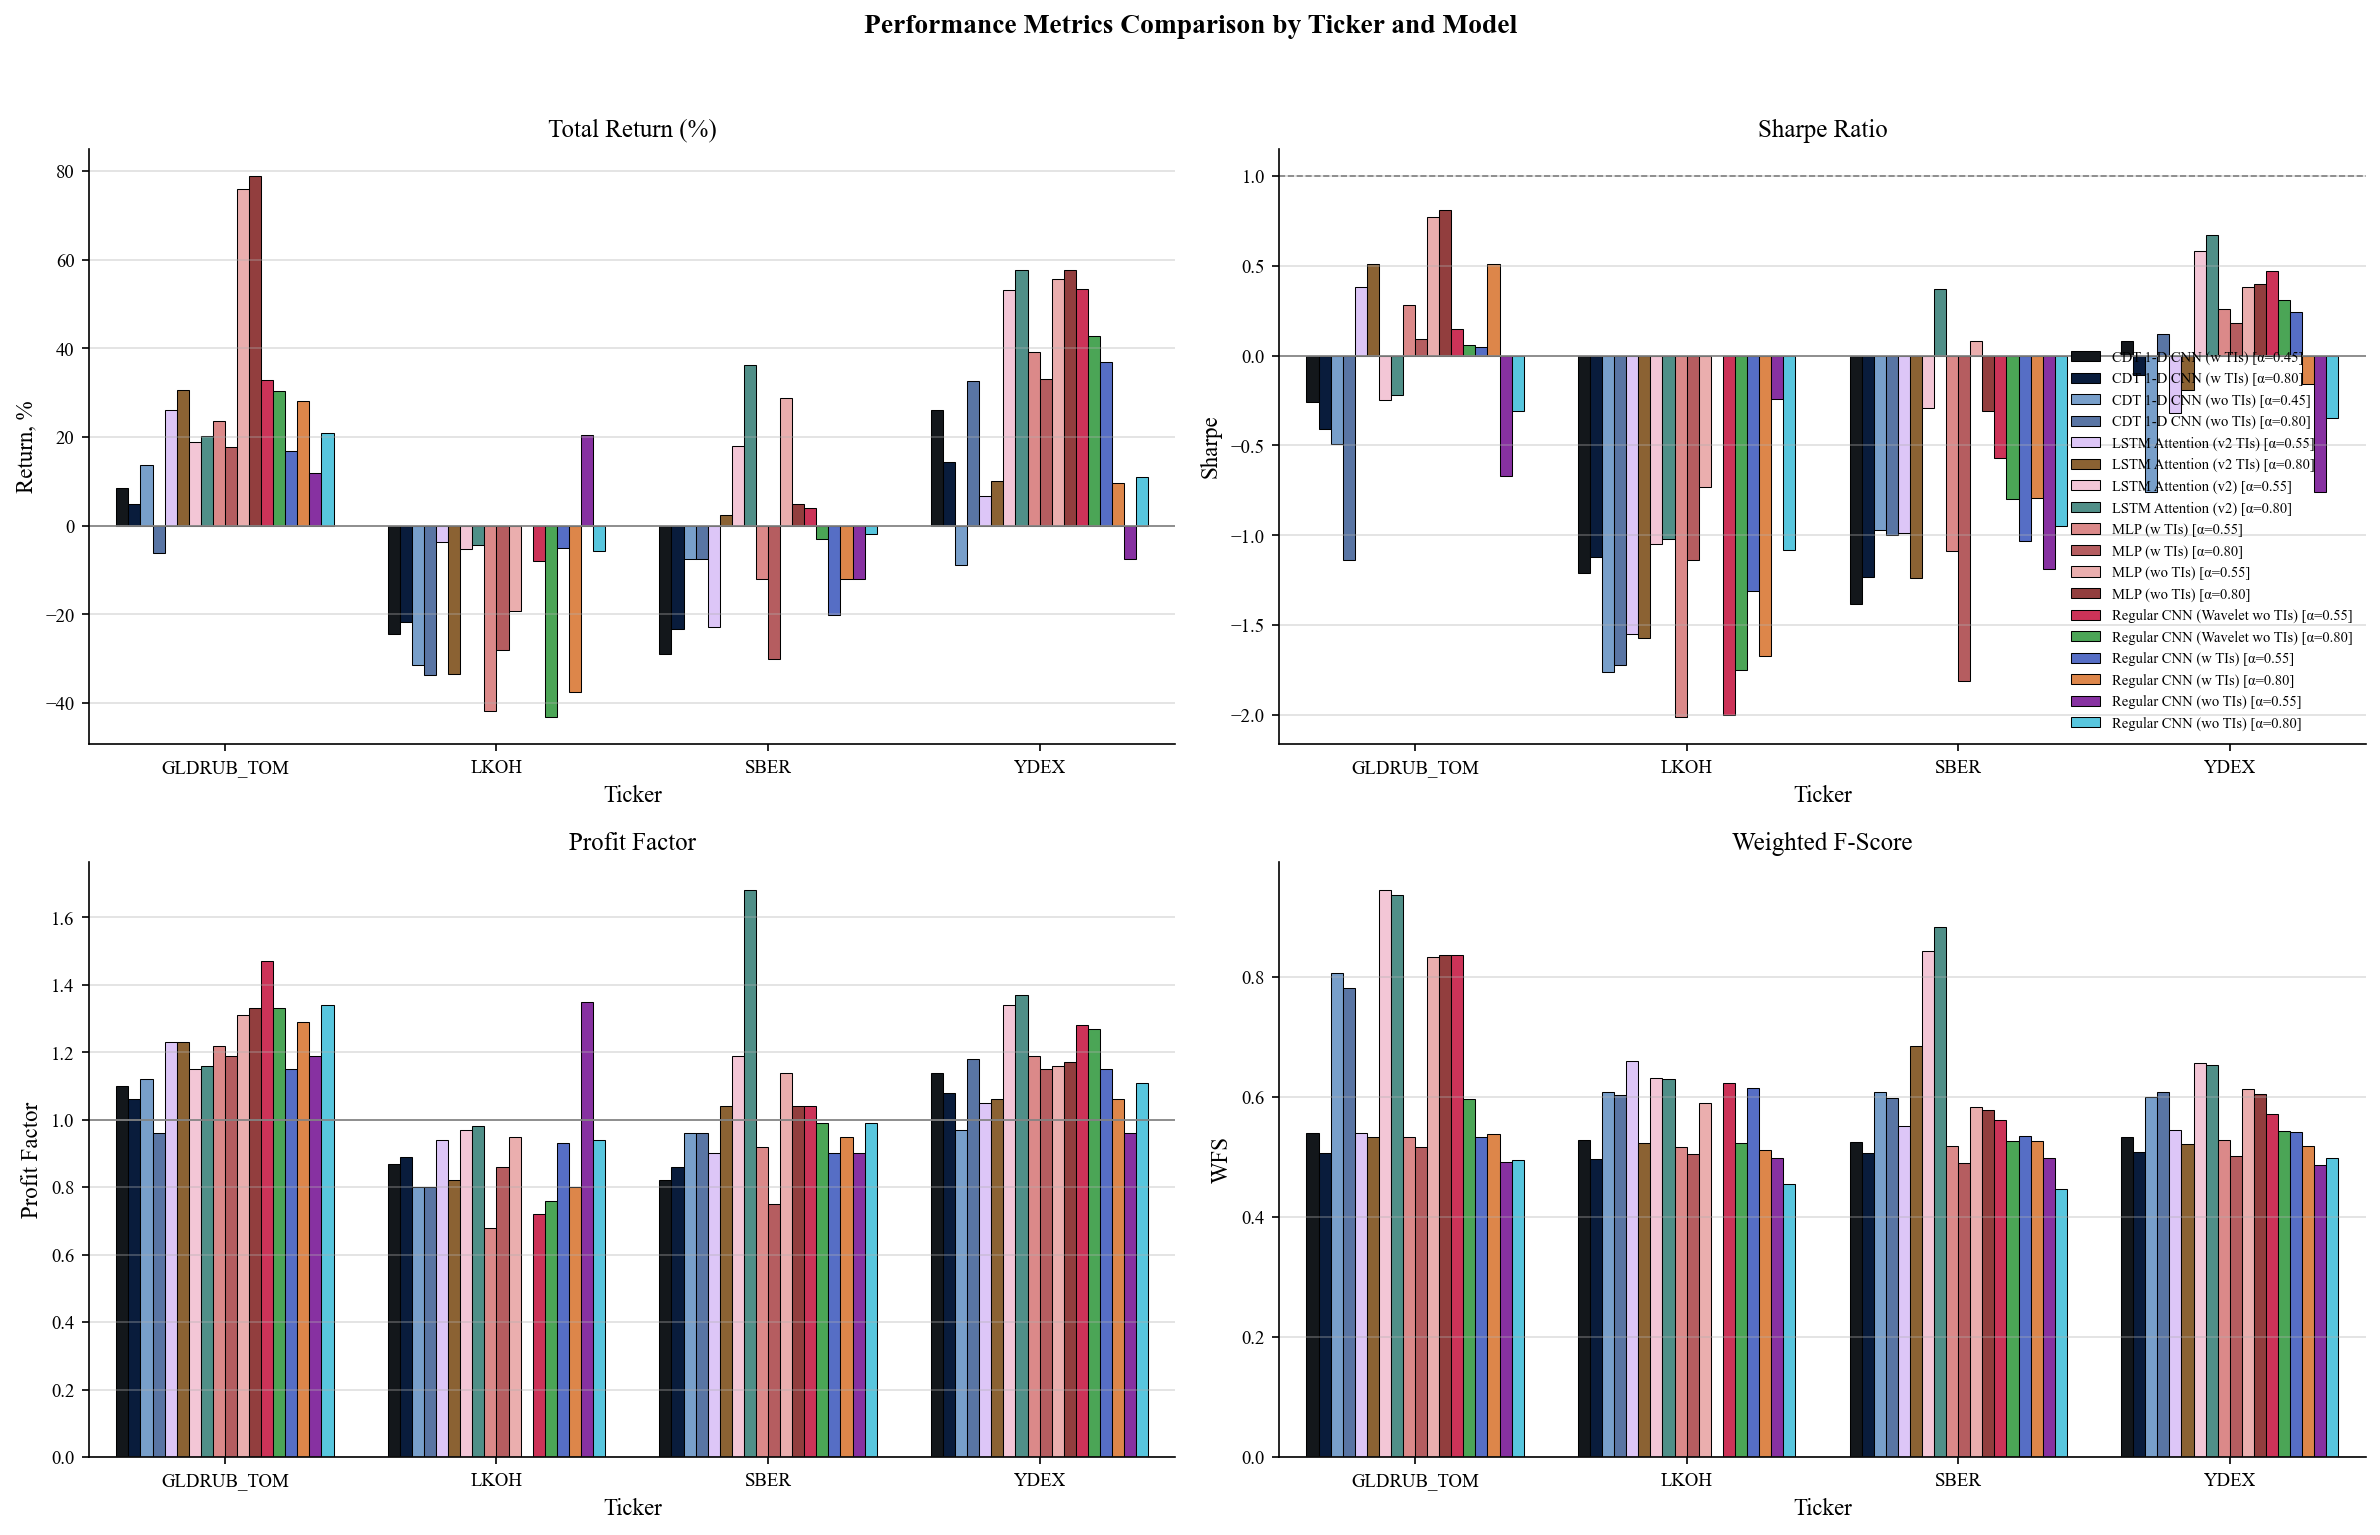

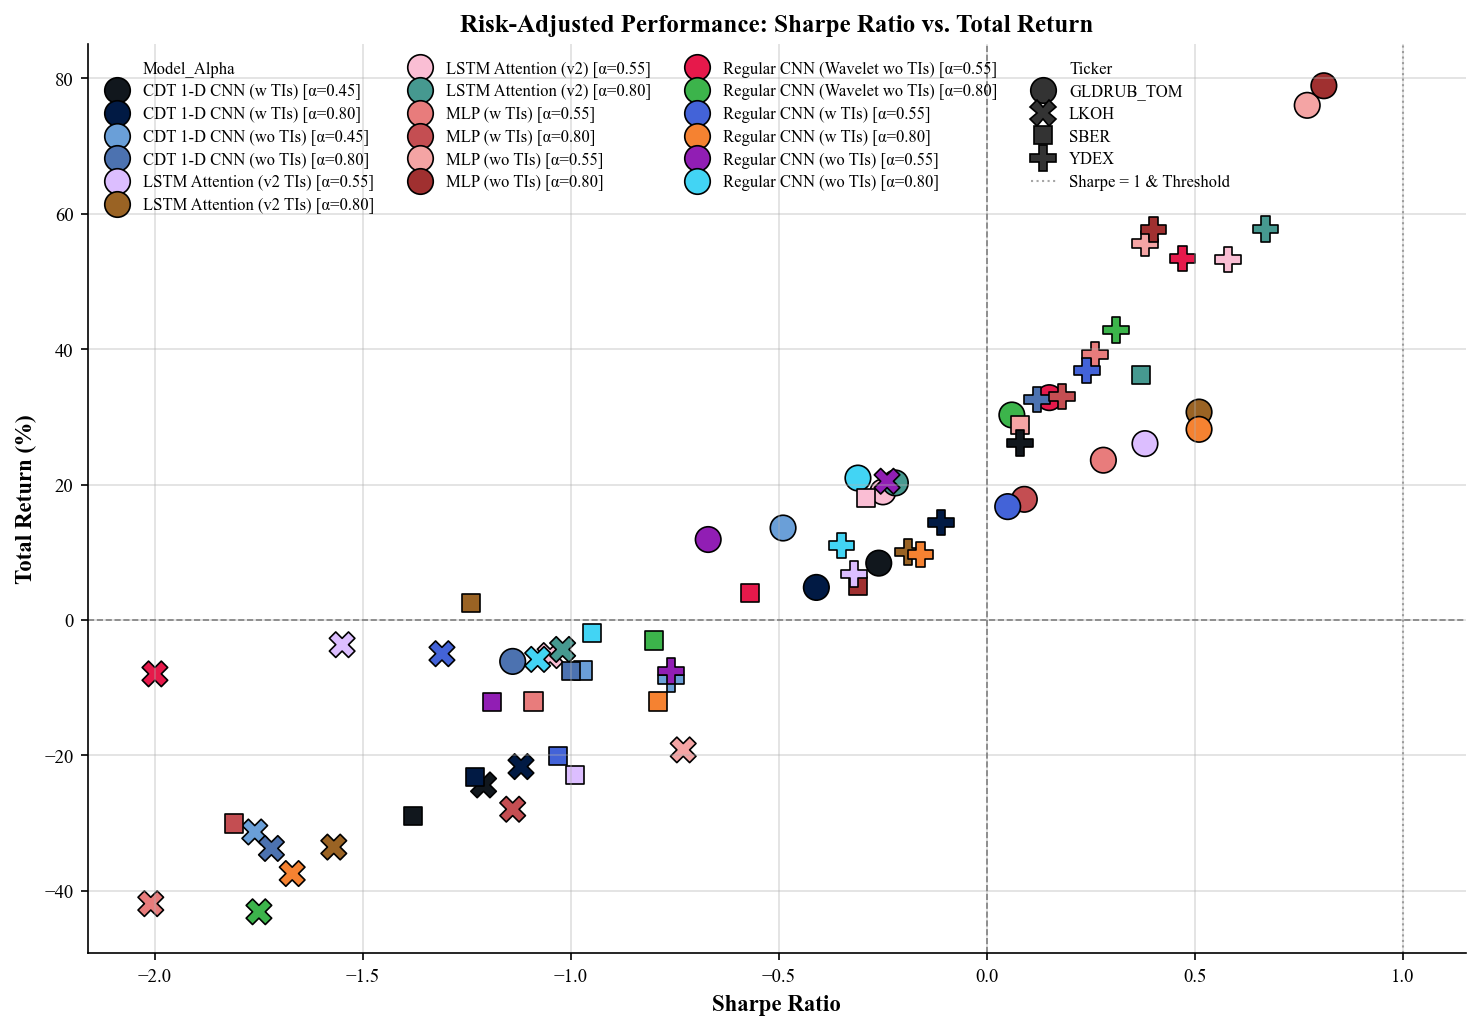

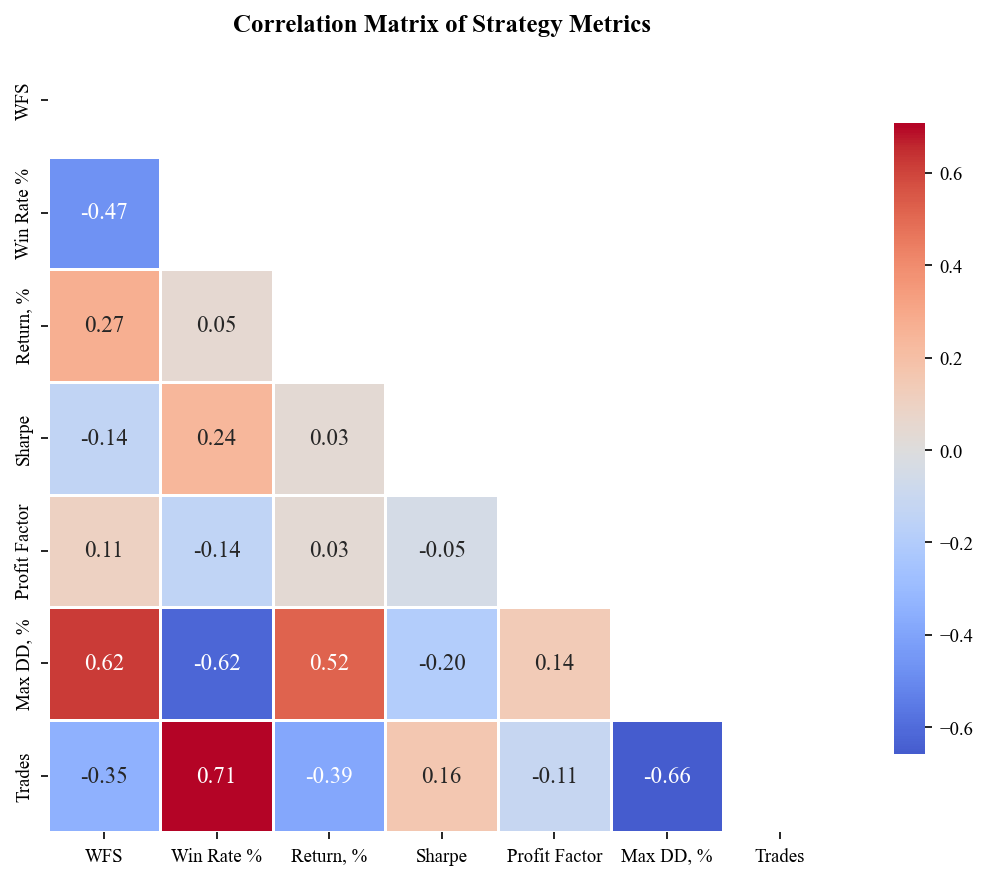

In [13]:
print("\nGenerating unified academic visualizations...")
plot_equity_curves(equity_curves_store, PLOTS_DIR)
plot_metrics_comparison(metrics_df, PLOTS_DIR)
plot_risk_return_scatter(metrics_df, PLOTS_DIR)
plot_correlation_heatmap(metrics_df, PLOTS_DIR)

In [14]:
# --- ИТОГОВАЯ ТАБЛИЦА: лучшие результаты по каждому Ticker + Model ---
best_per_model = metrics_df.loc[metrics_df.groupby(['Ticker', 'Model'])['Sharpe'].idxmax()].copy()

# Выбираем нужные столбцы (Alpha и Trades добавлены)
summary_cols = ['Ticker', 'Model', 'Alpha', 'Threshold', 'Trades',
                'Sharpe', 'Return, %', 'Max DD, %', 'Win Rate %',
                'Profit Factor', 'WFS', 'Signif.']

summary_table = best_per_model[summary_cols].sort_values(['Ticker', 'Sharpe'], ascending=[True, False]).reset_index(drop=True)

display(summary_table.style
        .format({'Sharpe': '{:.2f}', 'Return, %': '{:.2f}', 'Max DD, %': '{:.2f}',
                 'Win Rate %': '{:.1f}', 'Profit Factor': '{:.2f}', 'WFS': '{:.4f}',
                 'Threshold': '{:.2f}'})
        .set_caption('Best Strategy per Ticker & Model (with Alpha & Trades)')
)

excel_path = os.path.join(PLOTS_DIR, 'strategy_summary.xlsx')
with pd.ExcelWriter(excel_path, engine='xlsxwriter') as writer:
    summary_table.to_excel(writer, sheet_name='Best per Model', index=False)
    full_cols = ['Ticker', 'Model', 'Alpha', 'Threshold', 'Trades',
                 'Sharpe', 'Return, %', 'Max DD, %', 'Win Rate %',
                 'Profit Factor', 'WFS', 'Signif.']
    metrics_df[full_cols].sort_values(['Ticker', 'Model', 'Sharpe'], ascending=[True, True, False]).to_excel(
        writer, sheet_name='All Thresholds', index=False
    )
    
    for sheet_name in writer.sheets:
        worksheet = writer.sheets[sheet_name]
        for idx, col in enumerate(summary_cols):
            max_len = max(summary_table[col].astype(str).map(len).max(), len(col)) + 2
            worksheet.set_column(idx, idx, max_len)

print(f"\nТаблица сохранена: {excel_path}")

,Ticker,Model,Alpha,Threshold,Trades,Sharpe,"Return, %","Max DD, %",Win Rate %,Profit Factor,WFS,Signif.
0,GLDRUB_TOM,MLP (wo TIs),0.80,0.10,28,0.81,78.92,-13.80,37.6,1.33,0.8365,Yes
1,GLDRUB_TOM,LSTM Attention (v2 TIs),0.80,0.10,375,0.51,30.71,-13.21,49.2,1.23,0.5334,No
2,GLDRUB_TOM,Regular CNN (w TIs),0.80,0.35,368,0.51,28.16,-9.32,42.9,1.29,0.5375,Yes
3,GLDRUB_TOM,MLP (w TIs),0.55,0.10,7,0.28,23.60,-16.06,32.1,1.22,0.5327,No
4,GLDRUB_TOM,Regular CNN (Wavelet wo TIs),0.55,0.50,273,0.15,32.84,-8.13,22.4,1.47,0.8355,Yes
5,GLDRUB_TOM,LSTM Attention (v2),0.80,0.55,507,-0.22,20.24,-12.26,37.8,1.16,0.9369,No
6,GLDRUB_TOM,CDT 1-D CNN (w TIs),0.45,0.30,175,-0.26,8.39,-15.79,30.3,1.10,0.5390,No
7,GLDRUB_TOM,Regular CNN (wo TIs),0.80,0.25,239,-0.31,20.96,-8.51,17.9,1.34,0.4945,Yes
8,GLDRUB_TOM,CDT 1-D CNN (wo TIs),0.45,0.35,499,-0.49,13.58,-11.38,33.9,1.12,0.8068,No
9,LKOH,Regular CNN (wo TIs),0.55,0.35,241,-0.24,20.49,-10.40,13.0,1.35,0.4977,No



Таблица сохранена: ./Master_Thesis_Results/strategy_summary.xlsx


Всего статистически значимых стратегий в Топ-3: 7



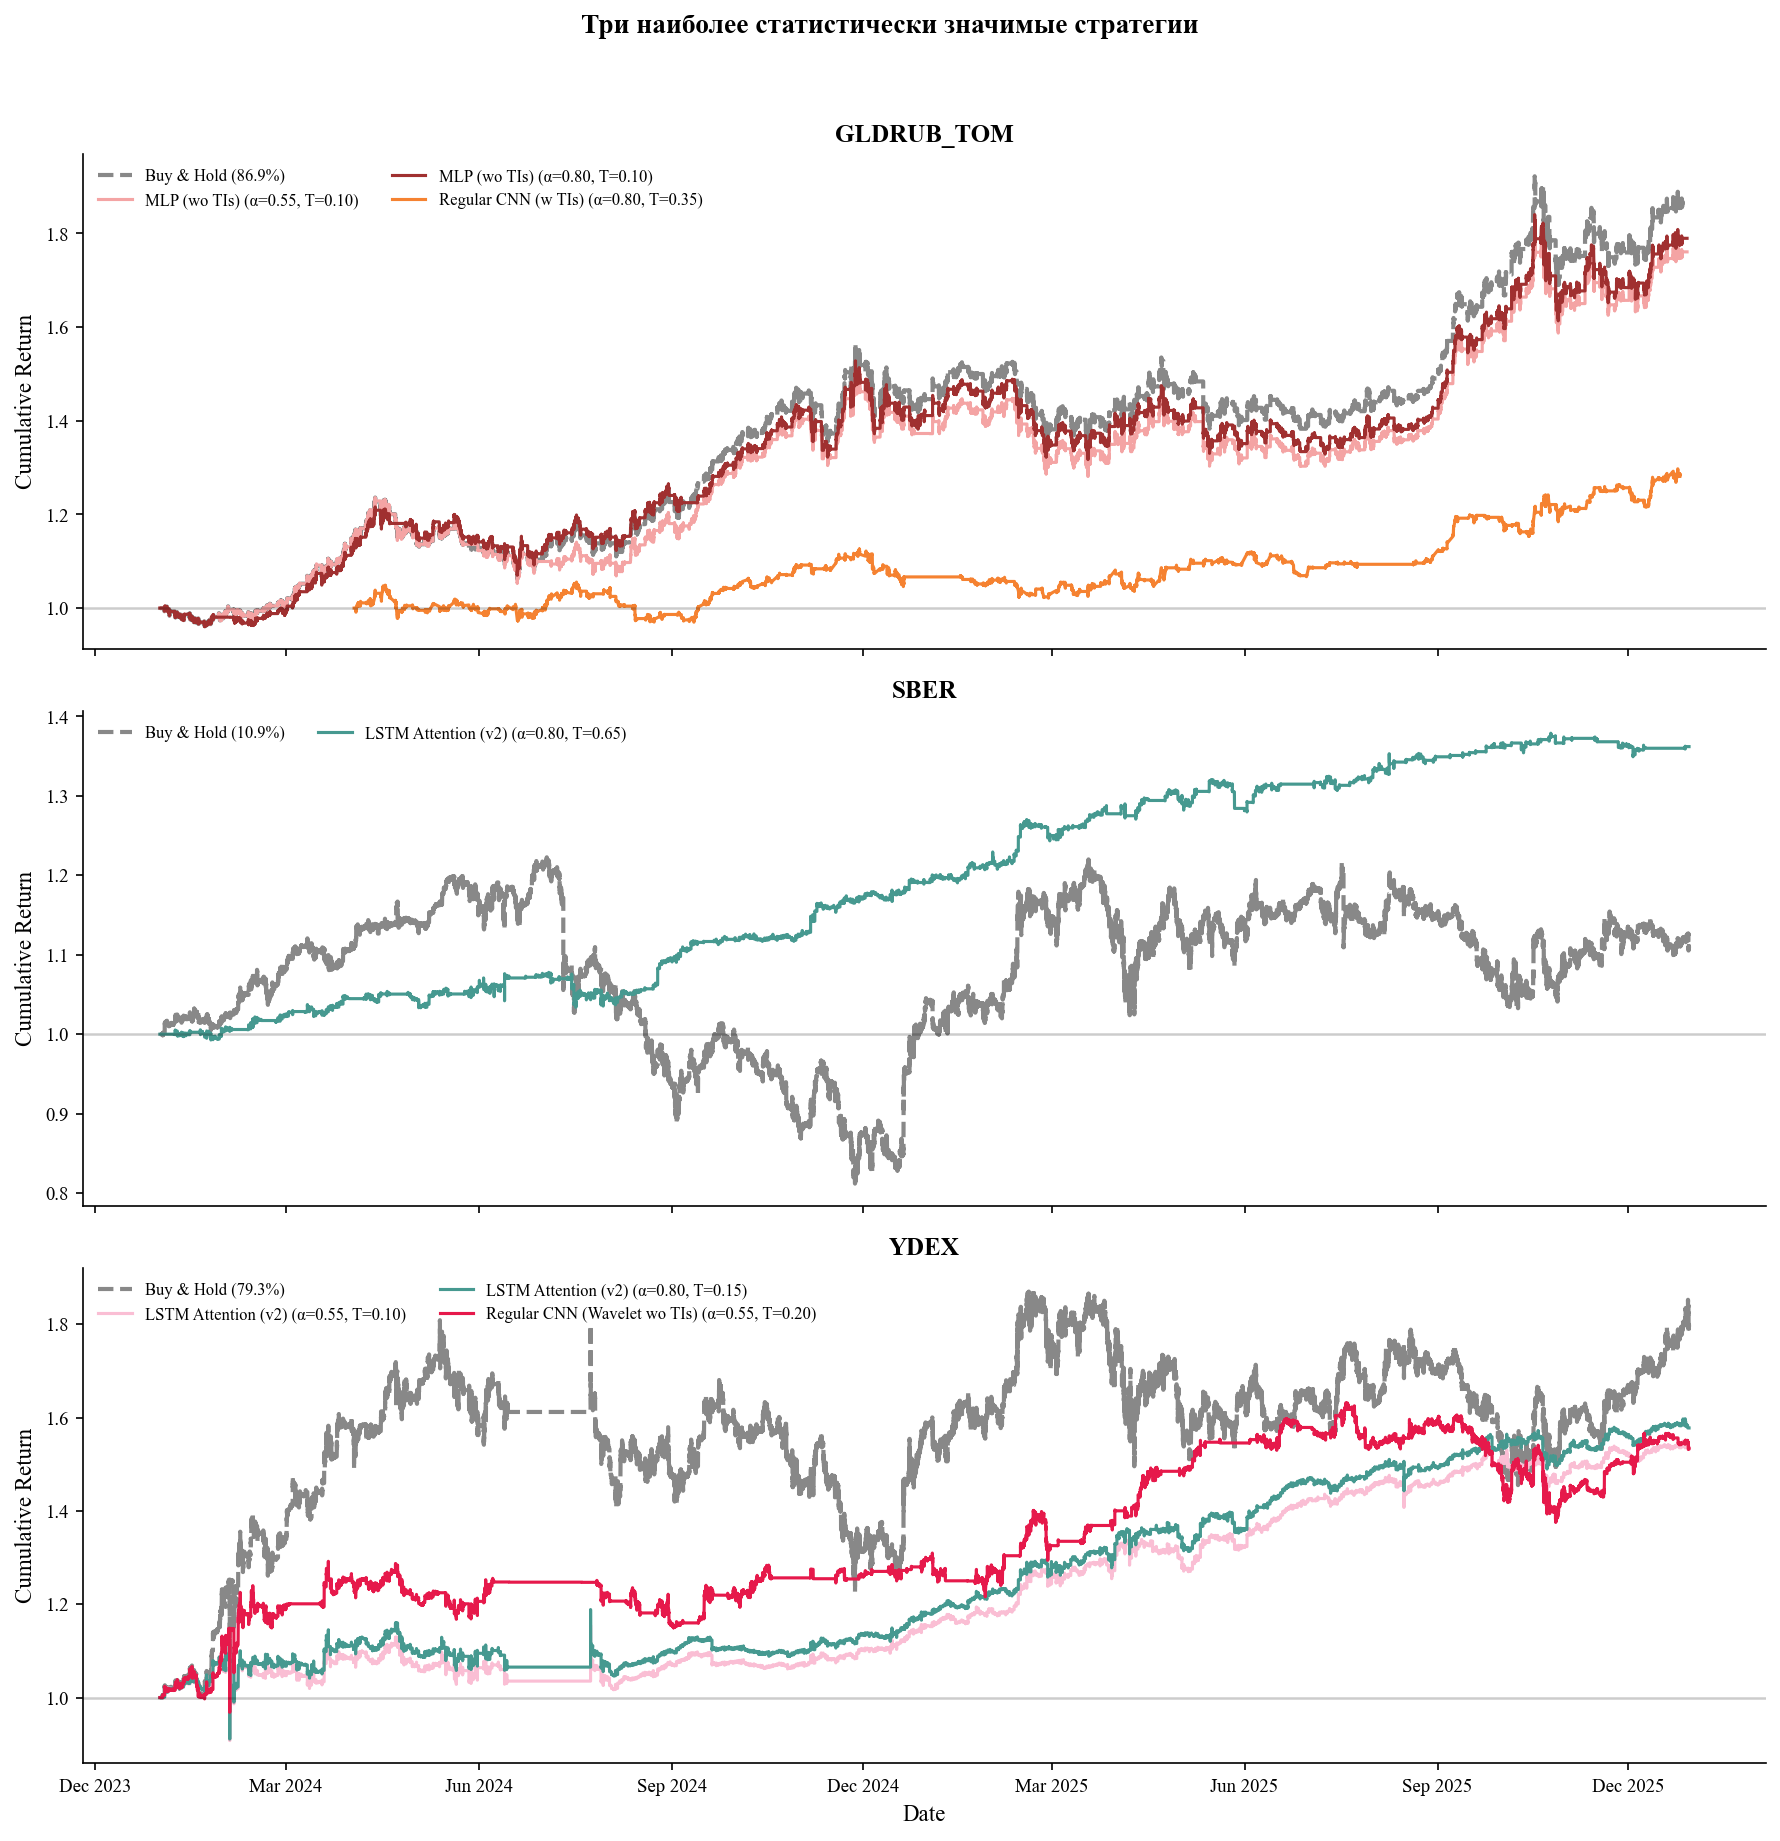

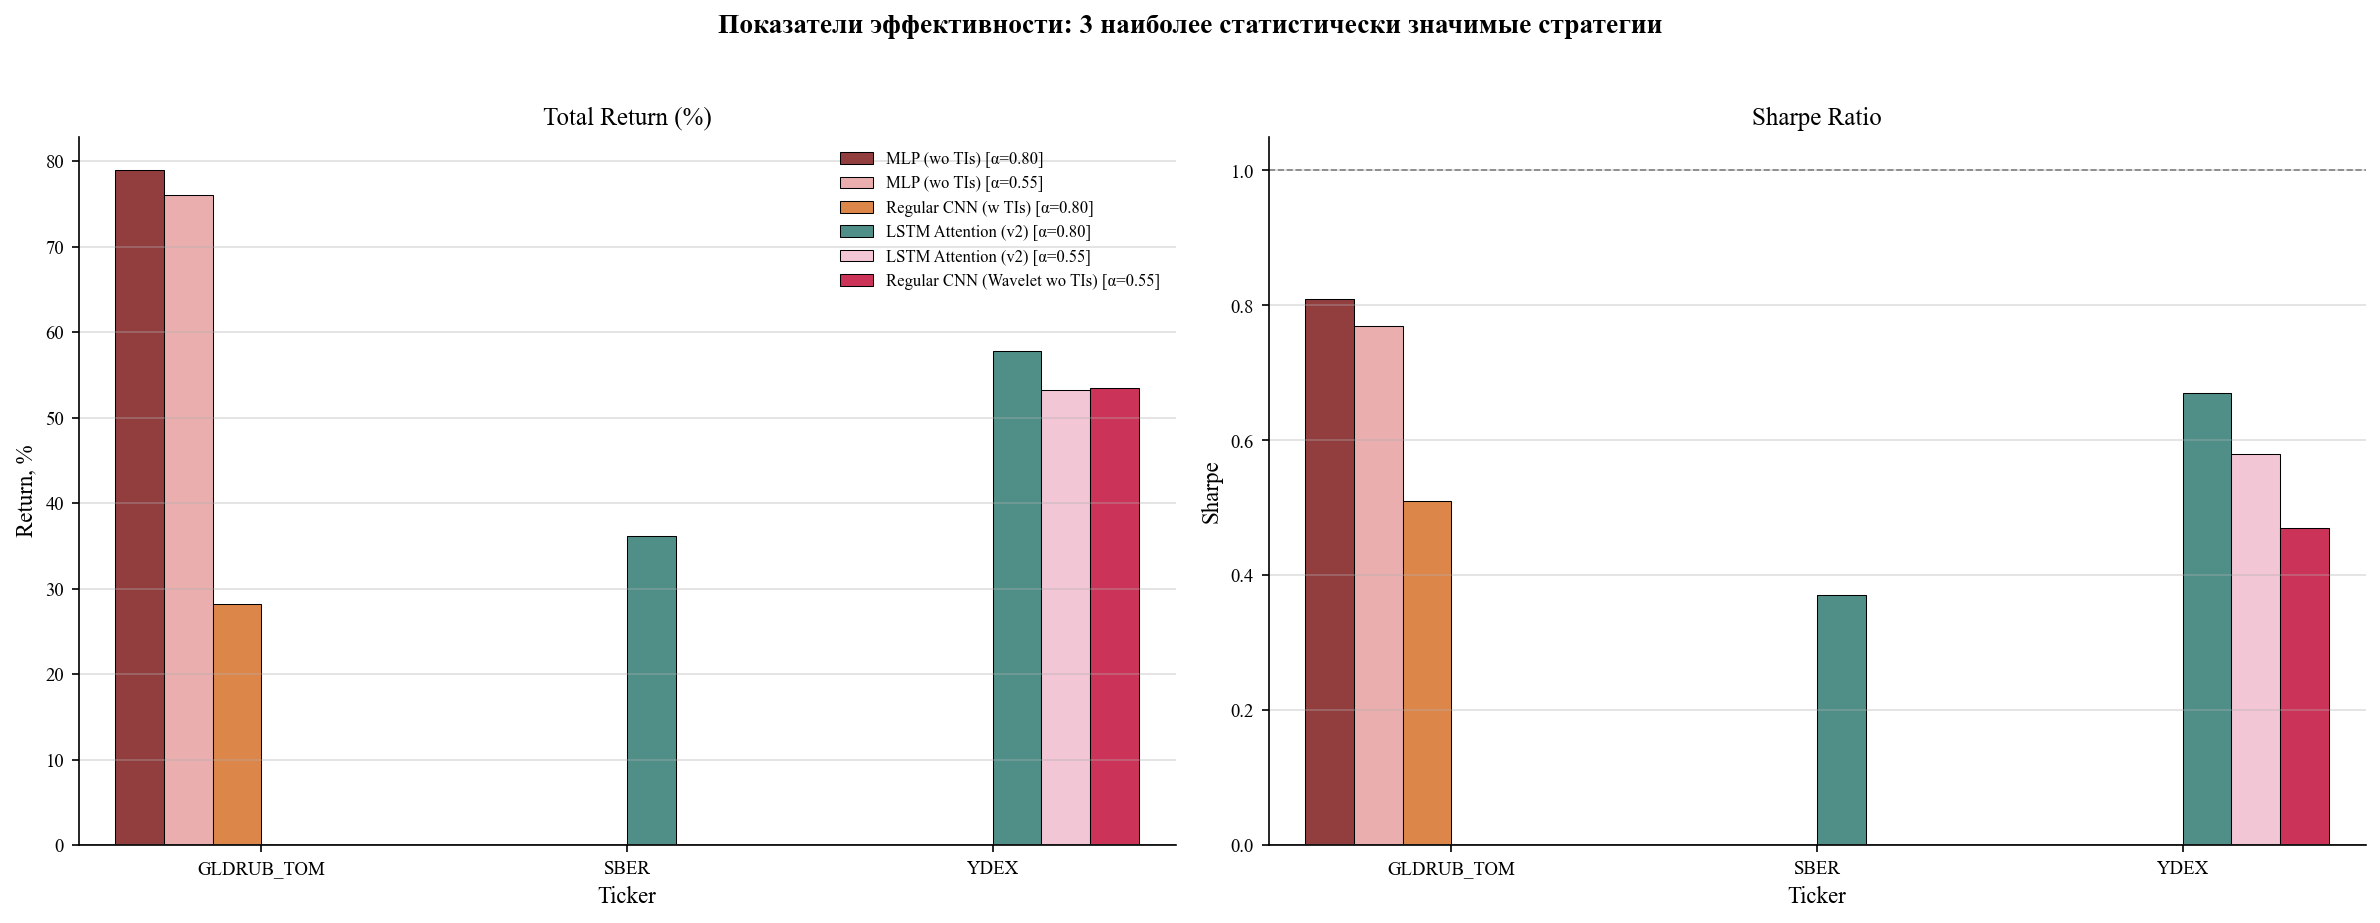

<Figure size 960x720 with 0 Axes>

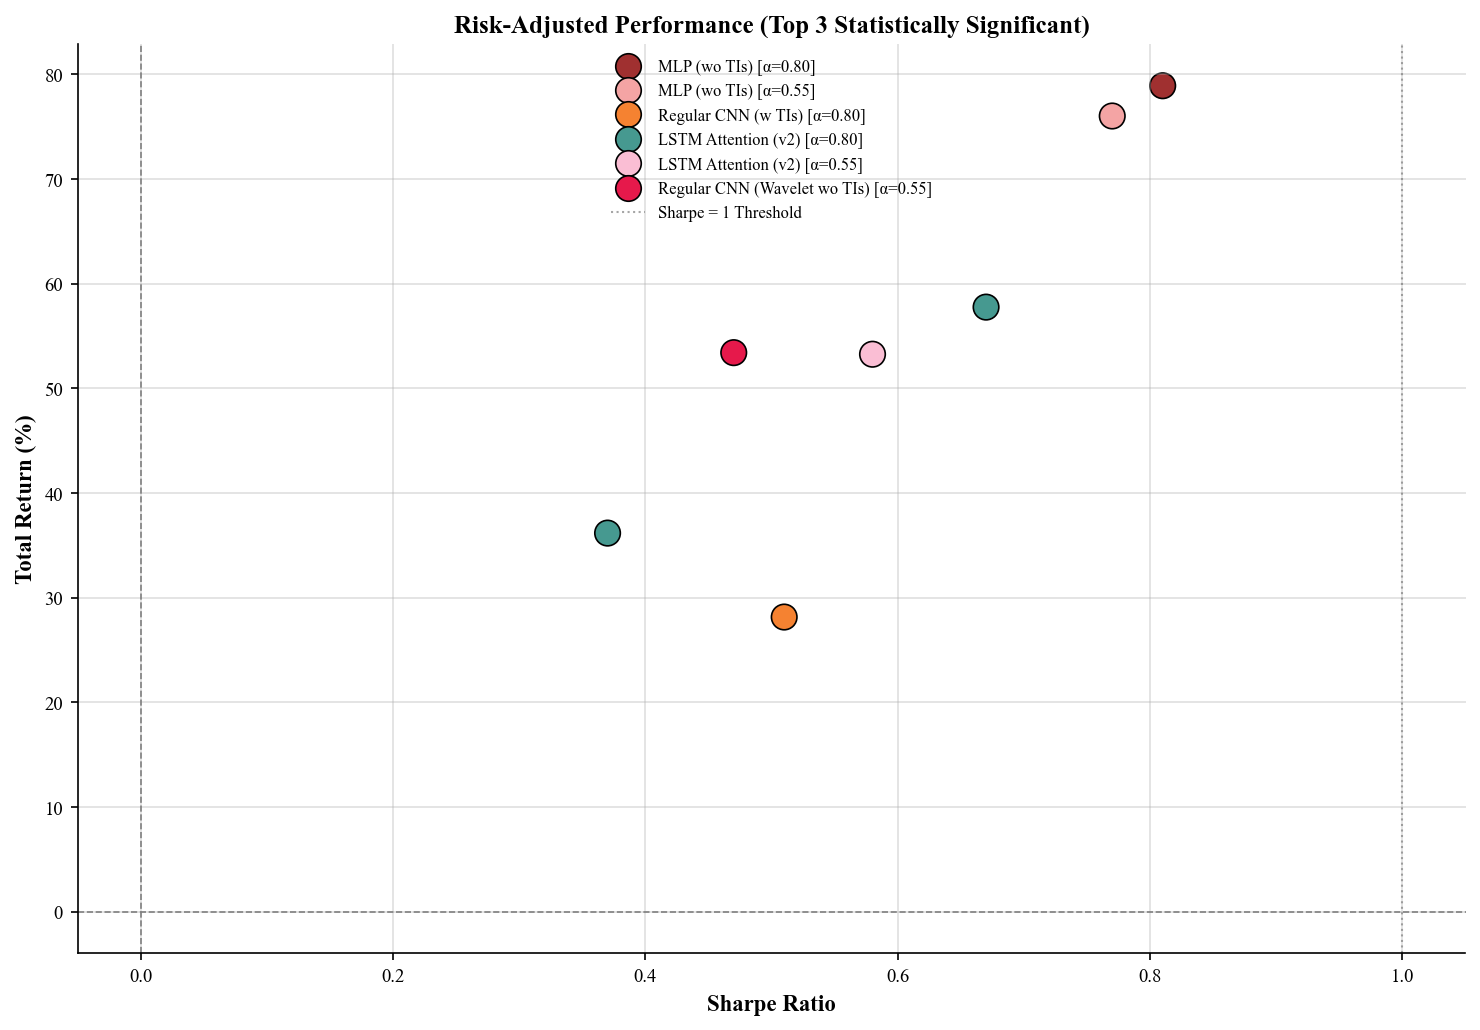

,Ticker,Model,Alpha,Trades,Sharpe,"Return, %",BH_Return,"Max DD, %",Win Rate %,Signif.
17,GLDRUB_TOM,MLP (wo TIs),0.80,28,0.81,78.92,86.88,-13.80,37.6,Yes
10,GLDRUB_TOM,MLP (wo TIs),0.55,6,0.77,76.03,86.88,-15.01,38.2,Yes
532,GLDRUB_TOM,Regular CNN (w TIs),0.80,368,0.51,28.16,86.88,-9.32,42.9,Yes
384,SBER,LSTM Attention (v2),0.80,488,0.37,36.18,10.89,-4.08,39.8,Yes
435,YDEX,LSTM Attention (v2),0.80,693,0.67,57.77,79.35,-16.75,52.7,Yes
418,YDEX,LSTM Attention (v2),0.55,701,0.58,53.27,79.35,-16.75,52.8,Yes
749,YDEX,Regular CNN (Wavelet wo TIs),0.55,501,0.47,53.42,79.35,-15.70,38.4,Yes


In [15]:
best_per_model_alpha = metrics_df.loc[metrics_df.groupby(['Ticker', 'Model', 'Alpha'])['Sharpe'].idxmax()].copy()

bh_benchmark = {}
for ticker, models_data in equity_curves_store.items():
    longest_df = max(models_data.values(), key=lambda x: x[0]['DateTime'].iloc[-1])[0]
    bh_benchmark[ticker] = round((longest_df['Price'].iloc[-1] / longest_df['Price'].iloc[0] - 1) * 100, 2)

best_per_model_alpha['BH_Return'] = best_per_model_alpha['Ticker'].map(bh_benchmark)

sig_best_df = best_per_model_alpha[best_per_model_alpha['Signif.'] == 'Yes'].copy()

if sig_best_df.empty:
    print("Ни одна стратегия не показала статистической значимости.")
else:
    top3_df = sig_best_df.sort_values(['Ticker', 'Sharpe'], ascending=[True, False]).groupby('Ticker').head(3).copy()

    if top3_df.empty:
        print("Нет статистически значимых стратегий для построения графиков.")
    else:
        top3_df['Model_Alpha'] = top3_df['Model'] + ' [α=' + top3_df['Alpha'].astype(str) + ']'
        
        top3_equity_store = {}
        for ticker, models_data in equity_curves_store.items():
            for model_alpha_key, (df_eval, thresh, alpha_val, model_name) in models_data.items():
                is_top3 = model_alpha_key in top3_df[top3_df['Ticker'] == ticker]['Model_Alpha'].values
                if is_top3:
                    if ticker not in top3_equity_store:
                        top3_equity_store[ticker] = {}
                    top3_equity_store[ticker][model_alpha_key] = (df_eval, thresh, alpha_val, model_name)

        print(f"Всего статистически значимых стратегий в Топ-3: {len(top3_df)}\n")
        
        tickers = list(top3_equity_store.keys())
        n_tickers = len(tickers)
        if n_tickers > 0:
            fig, axes = plt.subplots(n_tickers, 1, figsize=(12, 4 * n_tickers), sharex=True)
            if n_tickers == 1: axes = [axes]
            fig.suptitle('Три наиболее статистически значимые стратегии', y=1.02, fontweight='bold')

            for i, ticker in enumerate(tickers):
                ax = axes[i]
                models_data = top3_equity_store[ticker]
                
                longest_df = max(models_data.values(), key=lambda x: x[0]['DateTime'].iloc[-1])[0]
                bh_norm = longest_df['Price'] / longest_df['Price'].iloc[0]
                bh_return_val = bh_benchmark.get(ticker, 0)
                
                ax.plot(longest_df['DateTime'], bh_norm, label=f'Buy & Hold ({bh_return_val:.1f}%)', color=COLORS_DYNAMIC.get('Buy_Hold', '#888888'), linestyle='--', linewidth=2.0)

                for model_alpha_key, (df_eval, thresh, alpha_val, model_name) in models_data.items():
                    color = COLORS_DYNAMIC.get(model_alpha_key, 'black')
                    label_text = f'{model_name} (α={alpha_val}, T={thresh:.2f})'
                    ax.plot(df_eval['DateTime'], df_eval['Equity_Norm'], label=label_text, color=color, linewidth=1.5)

                ax.set_title(f'{ticker}', fontweight='bold')
                ax.set_ylabel('Cumulative Return')
                ax.legend(loc='upper left', frameon=False, ncol=2, fontsize=8)
                ax.axhline(y=1.0, color='black', linestyle='-', alpha=0.2)
                ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
                ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))

            plt.xlabel('Date')
            plt.tight_layout()
            plt.savefig(os.path.join(PLOTS_DIR, 'equity_curves_top3_sig.png'), bbox_inches='tight')
            plt.show()

        fig, axes = plt.subplots(1, 2, figsize=(16, 6))
        fig.suptitle('Показатели эффективности: 3 наиболее статистически значимые стратегии', fontweight='bold', y=1.02)
        
        sns.barplot(data=top3_df, x='Ticker', y='Return, %', hue='Model_Alpha', ax=axes[0], palette=COLORS_DYNAMIC, edgecolor='black', linewidth=0.5)
        axes[0].axhline(0, color='gray', linewidth=0.8)
        axes[0].set_title('Total Return (%)'); axes[0].legend(frameon=False, fontsize=8)
        
        sns.barplot(data=top3_df, x='Ticker', y='Sharpe', hue='Model_Alpha', ax=axes[1], palette=COLORS_DYNAMIC, edgecolor='black', linewidth=0.5)
        axes[1].axhline(0, color='gray', linewidth=0.8); axes[1].axhline(1, color='gray', linestyle='--', linewidth=0.8)
        axes[1].set_title('Sharpe Ratio'); axes[1].legend_.remove()

        for ax in axes.flat: ax.grid(axis='y', alpha=0.4)
        plt.tight_layout()
        plt.savefig(os.path.join(PLOTS_DIR, 'metrics_comparison_top3_sig.png'), bbox_inches='tight')
        plt.show()

        top3_palette = {k: COLORS_DYNAMIC.get(k, '#333333') for k in top3_df['Model_Alpha'].unique()}

        plt.clf()
        plt.figure(figsize=(10, 7))
        sns.scatterplot(
            data=top3_df, 
            x='Sharpe', 
            y='Return, %', 
            hue='Model_Alpha', 
            s=150, 
            palette=top3_palette, 
            edgecolor='black', 
            linewidth=0.8
        )
        plt.axhline(0, color='gray', linestyle='--', linewidth=0.8)
        plt.axvline(0, color='gray', linestyle='--', linewidth=0.8)
        plt.axvline(1, color='gray', linestyle=':', linewidth=1, alpha=0.7, label='Sharpe = 1 Threshold')
        plt.xlabel('Sharpe Ratio', fontweight='bold')
        plt.ylabel('Total Return (%)', fontweight='bold')
        plt.title('Risk-Adjusted Performance (Top 3 Statistically Significant)', fontweight='bold')
        plt.legend(frameon=False, fontsize=8)
        plt.grid(True, alpha=0.4)
        plt.tight_layout()
        plt.savefig(os.path.join(PLOTS_DIR, 'risk_return_scatter_top3_sig.png'), bbox_inches='tight')
        plt.show()

        display_cols = ['Ticker', 'Model', 'Alpha', 'Trades', 'Sharpe', 'Return, %', 'BH_Return', 'Max DD, %', 'Win Rate %', 'Signif.']
        display(top3_df[display_cols].sort_values(['Ticker', 'Sharpe'], ascending=[True, False]).style
                .format({'Sharpe': '{:.2f}', 'Return, %': '{:.2f}', 'BH_Return': '{:.2f}', 'Max DD, %': '{:.2f}', 'Win Rate %': '{:.1f}'})
                .set_caption('Top 3 Statistically Significant Strategies by Sharpe Ratio per Ticker'))